# Data preprocessing and analysis

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

Failed to read module file 'c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\Lib\re\_casefix.py' for module 're._casefix': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstr

In [2]:
from pathlib import Path

import scanpy as sc

from insitupy import CACHE, InSituData

c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
c:\Users\ge37voy\AppData\Local\miniconda3\envs\

## Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [3]:
# prepare paths
data_dir = Path(CACHE / "out/demo_insitupy_project") # directory of xenium data
xd = InSituData.read(data_dir)

In [4]:
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
UID:		None
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       'CD20':     (25778, 35416)
       'HE':       (25778, 35416, 3)
       'HER2':     (25778, 35416)
       'nuclei':   (25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           table
               AnnData object with n_obs × n_vars = 167780 × 313
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area'
               var: 'gene_ids', 'feature_types', 'genome'
               obsm: 'spatial'
           boundaries
               BoundariesData object with 2 entries:
                   cells
                   nuclei
    ➤ transcripts
       DataFrame with shape <dask_expr.expr.Scalar: expr=ReadParquetFSSpec(106110f).size() // 8, dtype=int64> x 8

## Explore data in interactive `napari` viewer

Example image of the viewer:

<left><img src="../../demo_data/demo_screenshots/whole_napari_viewer.jpg" width="800"/></left>

For detailed documentation on the functionalities of `napari` see the official documentation [here](https://napari.org/stable/index.html).

In [5]:
xd.show()

2026-10-06 15:33:42 | [INFO] Extracting unique gene names from Dask DataFrame...
2026-10-06 15:33:44 | [INFO] Found 541 unique genes


### Explore gene expression using `napari` viewer

Use the `"Add cells"` widget to explore the single-cell transcriptomic data.

<left><img src="../../demo_data/demo_screenshots/add_cells.jpg" width="350"/></left>

Genes can be selected from the dropdown window by scrolling or by clicking into the window and typing the name of the item:

<left><img src="../../demo_data/demo_screenshots/select_gene.jpg" width="350"/></left>

After selection of an item it can be added using the `"Add"` button. The data is added as point layer to the napari viewer.

## Perform preprocessing steps

`InSituPy` also includes basic preprocessing functions to normalize the transcriptomic data and perform dimensionality reduction. For normalization, the ``ScanPy`` function `sc.pp.normalize_total()` is used. Data transformation can be either done using logarithmic transformation or square root transformation as suggested [here](https://stlearn.readthedocs.io/en/latest/tutorials/Xenium_PSTS.html).

For a general introduction into preprocessing steps in single-cell transcriptomics analysis, the [single-cell best practices book](https://www.sc-best-practices.org/preamble.html) is a great ressource.


### Calculate QC metrics

Now we use the function `calculate_qc_metrics` to calculate the QC metrics, which we will afterwards use to filter the data and remove low quality cells. The function takes either an `InSituData` or `InSituExperiment` object. If you have multiple cell layers, it is important to specify the correct `cells_layer`.

In [6]:
from insitupy.preprocessing import calculate_qc_metrics

In [7]:
calculate_qc_metrics(xd, cells_layer="main", percent_top=None, log1p=False)

### Filtering

In our experience the QC metrices can vary a lot between different samples. Therefore, it is important to explore every dataset separately before making decisions on filtering thresholds. Also, it can be beneficial to try to split the dataset before filtering into different cell lineages (e.g. epithelial vs. non-epithelial) and use different thresholds per lineage, since even within cell types there can be large variations in the QC metrices. This can be especially the case for technologies like Xenium where a rather small gene panel is used and the transcript counts depend a lot on whether the panel contains marker genes of a certain cell type or not.

In [8]:
from insitupy.plotting import plot_qc_metrics

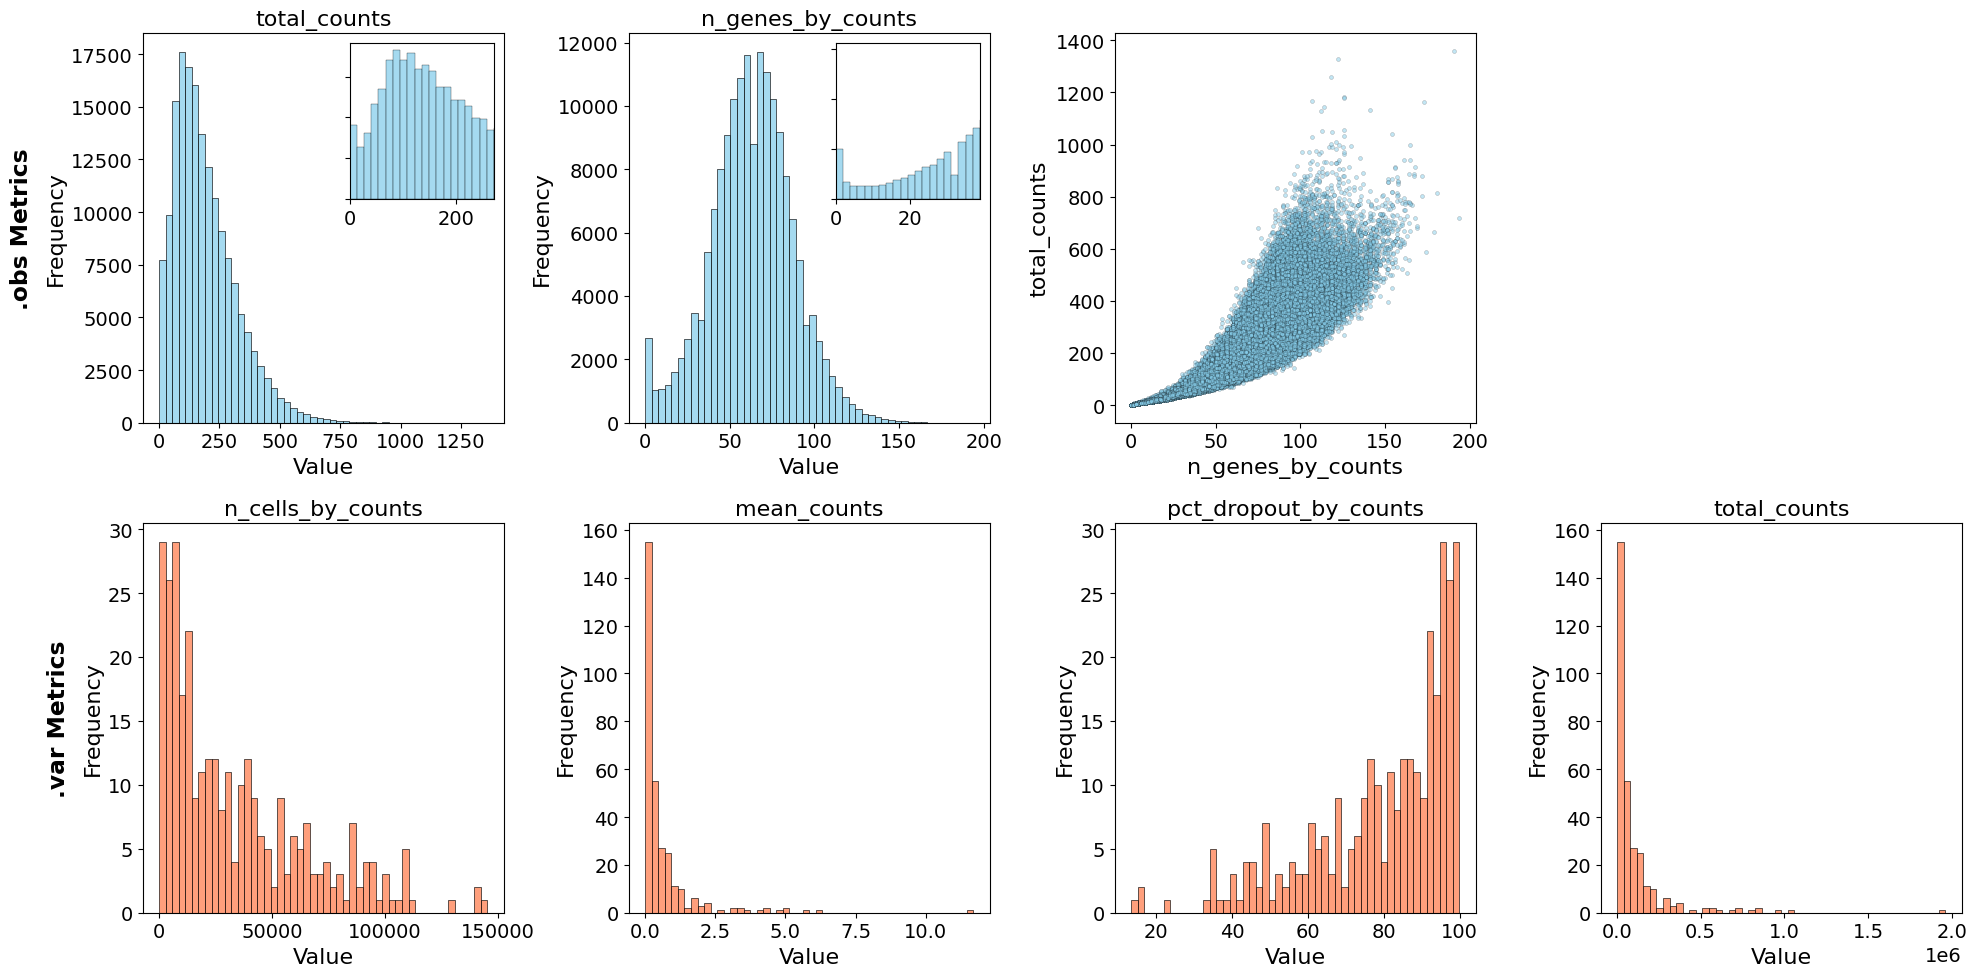

In [9]:
plot_qc_metrics(xd, show_inset=True)

For filtering there are different options, but in this case we chose to filter on two parameters: `n_genes_by_counts` and `n_cell_by_counts`. The first parameter filters out cells (`.obs`) in which only a very small number of genes were found and the second parameter filters out genes (`.var`) which were only found in a very small number of cells. As threshold we chose cells with less than 25 genes and genes which were found in less than 1% of the cells. Filtering of cells happens on the level of `.cells.table`. To synchronize the cells included in `.cells.table` and their boundaries in `.cells.boundaries` after the filtering, `.sync` is called within the `filter_cells` function.

In [10]:
from insitupy.preprocessing import filter_cells, filter_genes

In [11]:
filter_cells(xd, min_genes=25)

In [12]:
xd.cells.table

AnnData object with n_obs × n_vars = 157600 × 313
    obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'

In [13]:
cell_number = xd.cells.table.shape[0]
cell_threshold = int(cell_number * 0.01)
print(f"Threshold for cells per gene: {cell_threshold}")

Threshold for cells per gene: 1576


In [14]:
filter_genes(xd, min_cells=cell_threshold)

In [15]:
xd.cells.table

AnnData object with n_obs × n_vars = 157600 × 297
    obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    obsm: 'spatial'

After the filter the QC metrices look as follows:

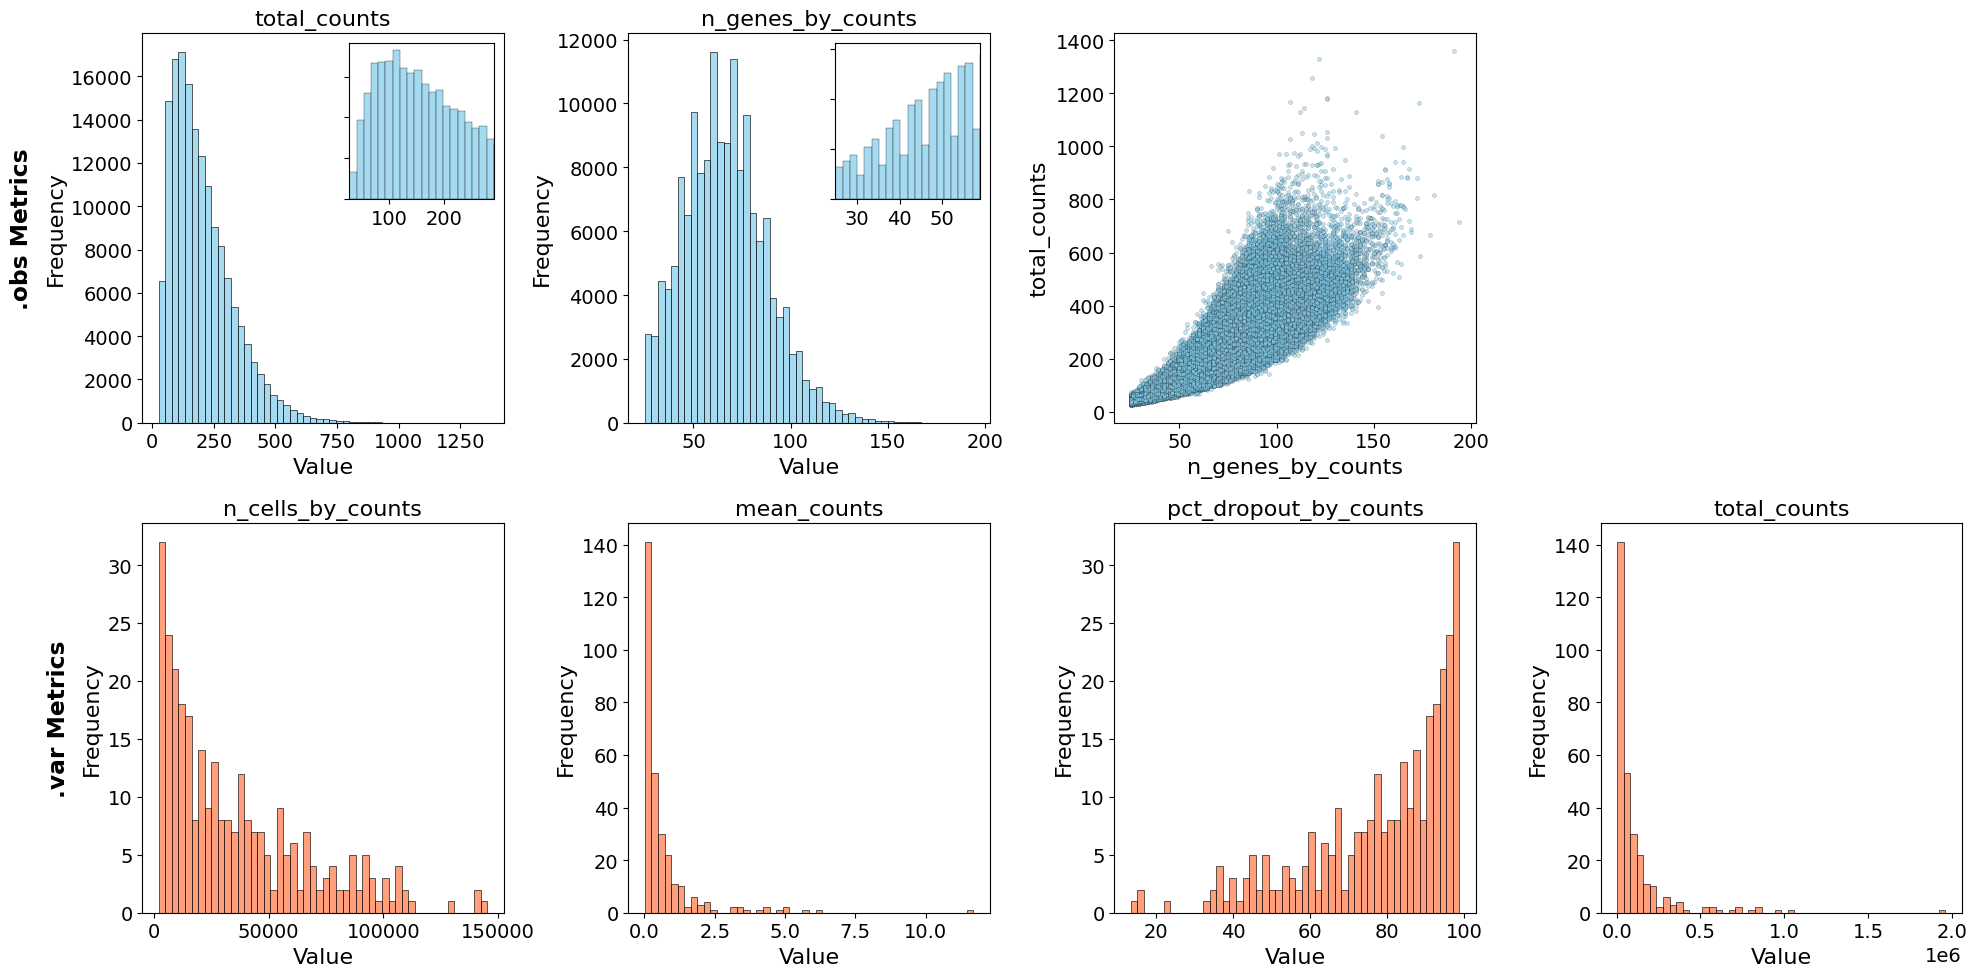

In [16]:
plot_qc_metrics(xd)

### Normalization and transformation

Two transformation methods were suggested for transforming in situ sequencing data: log-transformation and square root-transformation. To test which one is better suited for the current dataset, the `test_transformation` function can be used.

In [17]:
from insitupy.plotting import test_transformations

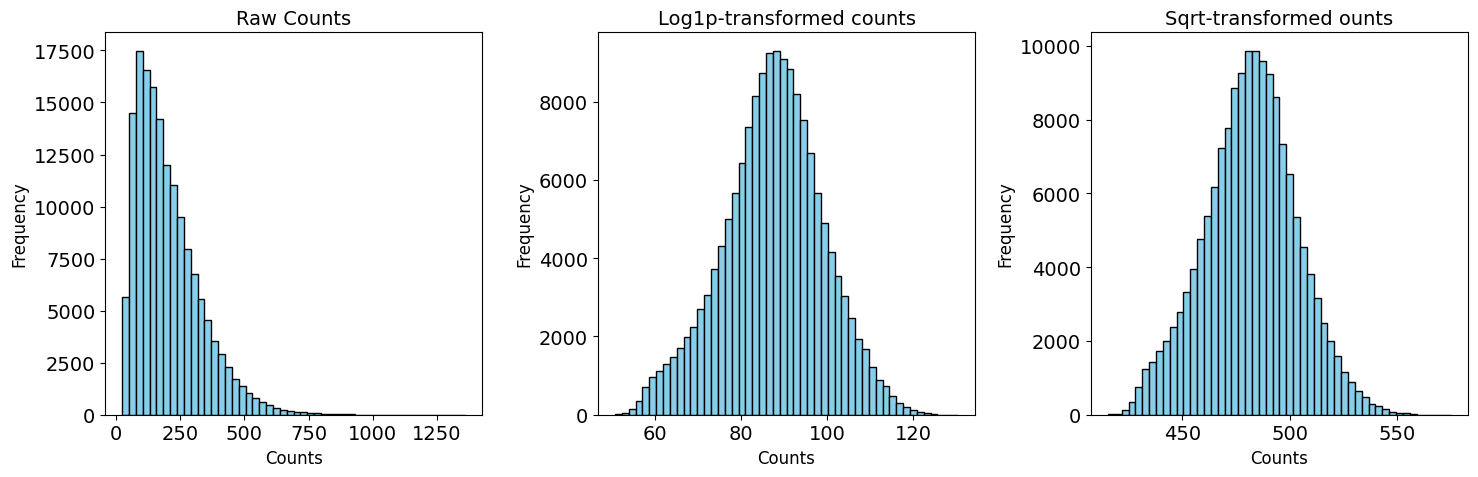

In [18]:
test_transformations(
    xd, target_sum=250, scale=False
    )

Here, we decided to continue with the log-transformation, which is also the most common approach.

In [19]:
from insitupy.preprocessing import normalize_and_transform

In [20]:
normalize_and_transform(
    data=xd,
    transformation_method="log1p",
    target_sum=250,
    scale=False,
    verbose=True
    )

2026-10-06 15:34:44 | [INFO] Store raw counts in .layers['counts'].
2026-10-06 15:34:44 | [INFO] Normalization with target sum 250.
2026-10-06 15:34:45 | [INFO] Perform log1p-transformation.


### Dimensionality reduction

Calculating the UMAP can take about 5-10 min due to the size of the dataset.

In [21]:
from insitupy.preprocessing import cluster_cells, reduce_dimensions

In [22]:
reduce_dimensions(
    data=xd,
    cells_layer="main",
    n_neighbors=15,
    n_pcs=None
    )

In [23]:
cluster_cells(
    data=xd,
    cells_layer="main", # or None to use the layer specified in .main_key
    method="leiden"
)

### Show results using `scanpy` functions

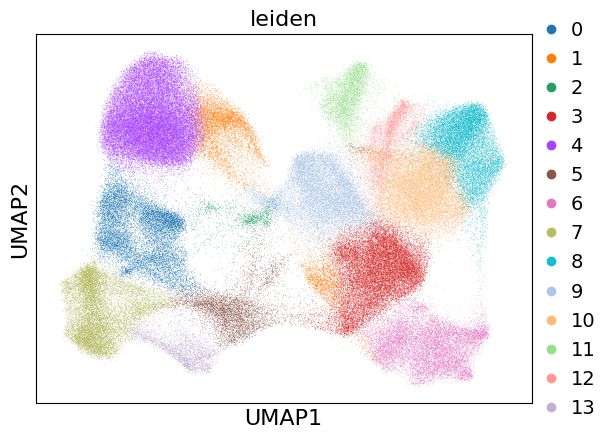

In [24]:
sc.pl.umap(xd.cells.table, color=["leiden"])

In [25]:
# visualize data
xd.show()

2026-10-06 15:38:50 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 1086x655-1279+345 (frame: 1102x694-1287+314) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY2". Resulting geometry: 723x500-1282+331 (frame: 739x539-1290+300) margins: 8, 31, 8, 8 minimum size: 385x500 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=401,539 maxtrack=0,0)


2026-10-06 15:38:58 | [INFO] Extracting unique gene names from Dask DataFrame...
2026-10-06 15:39:01 | [INFO] Found 541 unique genes


#### Start viewer with list of selected genes

Alternatively to selecting genes inside the napari viewer, it is also possible to open the viewer directly including a list of genes.

In [26]:
xd.show(keys=["leiden", "ACTA2", "LYZ", "LUM"])

2026-10-06 15:39:08 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 1086x655-1282+340 (frame: 1102x694-1290+309) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY2". Resulting geometry: 723x500-1285+326 (frame: 739x539-1293+295) margins: 8, 31, 8, 8 minimum size: 385x500 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=401,539 maxtrack=0,0)


2026-10-06 15:39:21 | [INFO] Extracting unique gene names from Dask DataFrame...
2026-10-06 15:39:23 | [INFO] Found 541 unique genes


Genes can be displayed or hidden via the eye symbol: <br>
<left><img src="../../demo_data/demo_screenshots/gene_selection.jpg" height="70"/></left>

## Save results within `InSituPy` project

The processed data can be saved into a folder using the `.saveas()` function of `InSituData`.

The resulting folder has following structure (can vary depending on which modalities have been loaded before):
```
insitupy_project_folder
│   .ispy
│
├───cells
│   └───uid
│       │   .celldata
│       │
│       ├───boundaries
│       │       cellular.zarr.zip
│       │       nuclear.zarr.zip
│       │
│       └───matrix
│               matrix.h5ad
│
├───images
│       morphology_mip.zarr.zip
│       slide_id__sample_id__CD20__registered.zarr.zip
│       slide_id__sample_id__HER2__registered.zarr.zip
│       slide_id__sample_id__HE__registered.zarr.zip
│
└───transcripts
        transcripts.parquet
```

In [27]:
xd.save()

2026-10-06 15:39:51 | [INFO] Saving to existing path: C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project
2026-10-06 15:39:51 | [INFO] Updating project in C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project
2026-10-06 15:39:51 | [INFO] Updating cells...
2026-10-06 15:40:33 | [INFO] Saved.


In [28]:
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
UID:		None
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       'CD20':     (25778, 35416)
       'HE':       (25778, 35416, 3)
       'HER2':     (25778, 35416)
       'nuclei':   (25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           table
               AnnData object with n_obs × n_vars = 157600 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'insitupy', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
               obsm: 'X_pca', 'X_umap', 'spatial'
               varm: 'PCs'
               layers: 'counts', 'norm_counts'
               obsp: 